# RepoEval — Experiment Result Figures & Tables

This notebook generates all figures and tables for the RepoEval benchmark results.

Data source: `eval/repoeval/result/{api,line}_all_results.csv`

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path

# Paths
RESULT_DIR = Path("../repoeval/result")
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load data
api_df = pd.read_csv(RESULT_DIR / "api_all_results.csv")
api_df["split"] = "api"
line_df = pd.read_csv(RESULT_DIR / "line_all_results.csv")
line_df["split"] = "line"
df = pd.concat([api_df, line_df], ignore_index=True)

# Filter out starcoder2-7b
df = df[df["llm"] != "starcoder2-7b"]

# Separate baseline and RAG configurations
baseline = df[df["method"] == "baseline"].copy()
rag = df[df["method"] != "baseline"].copy()

print(f"Total rows: {len(df)}, RAG rows: {len(rag)}, Baseline rows: {len(baseline)}")
print(f"Methods: {sorted(rag['method'].unique())}")
print(f"Retrievers: {sorted(rag['retriever'].unique())}")
print(f"LLMs: {sorted(rag['llm'].unique())}")

Total rows: 1160, RAG rows: 1152, Baseline rows: 8
Methods: ['cast', 'declaration', 'function', 'sliding']
Retrievers: ['Qwen3-Embedding-0.6B', 'Qwen3-Embedding-4B', 'bm25', 'embeddinggemma-300m']
LLMs: ['Qwen2.5-Coder-7B', 'Qwen3.5-9B-Base', 'Seed-Coder-8B-Base', 'deepseek-coder-6.7b-base']


## RQ1: Strategy Effect — Table

Mean EM per chunking method, averaged across all retriever × LLM × parameter configurations.
Export: CSV only. LaTeX tabular filled manually in the main tex file.

In [36]:
# RQ1 — Mean EM & ES per method across all configurations
# Export: output/repoeval_rq1_strategy_effect.csv

rq1_em = df.groupby(["method", "split"])["EM"].agg(["mean", "std"]).reset_index()
rq1_em.columns = ["method", "split", "EM", "EM_std"]
rq1_es = df.groupby(["method", "split"])["ES"].agg(["mean", "std"]).reset_index()
rq1_es.columns = ["method", "split", "ES", "ES_std"]
rq1 = rq1_em.merge(rq1_es, on=["method", "split"])
rq1 = rq1.sort_values(["split", "method"])
rq1.to_csv(OUTPUT_DIR / "repoeval_rq1_strategy_effect.csv", index=False)

print("Exported to output/repoeval_rq1_strategy_effect.csv")
print(rq1.to_string(index=False))

Exported to output/repoeval_rq1_strategy_effect.csv
     method split       EM   EM_std       ES   ES_std
   baseline   api 0.341250 0.032005 0.628000 0.022254
       cast   api 0.459342 0.020275 0.728392 0.013988
declaration   api 0.458476 0.019221 0.717864 0.014089
   function   api 0.422710 0.017827 0.692458 0.015166
    sliding   api 0.462285 0.020014 0.729950 0.013722
   baseline  line 0.437975 0.029645 0.665300 0.021562
       cast  line 0.565395 0.018534 0.750622 0.013017
declaration  line 0.548378 0.019271 0.738912 0.013429
   function  line 0.512731 0.021358 0.717542 0.016255
    sliding  line 0.569084 0.019972 0.752098 0.013680


## RQ1: Strategy Effect — Statistical Tests

Pairwise Wilcoxon signed-rank + Cliff's delta across all 6 strategy pairs.
Each observation = EM of one (retriever × LLM × chunk_size × context_length) configuration (n=144 per strategy).
Correction: Holm–Bonferroni for 6 comparisons.

In [37]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS_MAP = {
    "function": "Function", "declaration": "Declaration",
    "sliding": "Sliding Window", "cast": "cAST"
}

def cliffs_delta(x, y):
    """Cliff's delta for paired samples."""
    n = len(x)
    more = sum(1 for i in range(n) if x[i] > y[i])
    less = sum(1 for i in range(n) if x[i] < y[i])
    return (more - less) / n

def interpret_delta(d):
    d = abs(d)
    if d < 0.147:   return "Negligible"
    elif d < 0.33:  return "Small"
    elif d < 0.474: return "Medium"
    else:           return "Large"

pairs = list(combinations(METHOD_ORDER, 2))
all_results = []

for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]
    pivot = sub.pivot_table(
        index=["retriever", "llm", "max_chunk_size", "max_crossfile_context"],
        columns="method", values="EM"
    )

    p_values = []
    results = []
    for a, b in pairs:
        x, y = pivot[a].values, pivot[b].values
        stat, p = wilcoxon(x, y)
        delta = cliffs_delta(x, y)
        p_values.append(p)
        results.append({
            "split": split_name,
            "strategy_A": METHOD_LABELS_MAP[a],
            "strategy_B": METHOD_LABELS_MAP[b],
            "wilcoxon_stat": stat,
            "p_raw": p,
            "cliffs_delta": round(delta, 4),
            "effect_size": interpret_delta(delta),
        })

    rejected, corrected_p, _, _ = multipletests(p_values, method="holm")
    for i, r in enumerate(results):
        r["p_corrected"] = corrected_p[i]
        r["significant"] = "Yes" if rejected[i] else "No"

    all_results.extend(results)

rq1_stat_df = pd.DataFrame(all_results)
rq1_stat_df = rq1_stat_df[["split", "strategy_A", "strategy_B", "wilcoxon_stat",
                    "p_raw", "p_corrected", "significant", "cliffs_delta", "effect_size"]]

rq1_stat_df.to_csv(OUTPUT_DIR / "repoeval_rq1_statistical_tests.csv", index=False)
print("Exported to output/repoeval_rq1_statistical_tests.csv\n")
print(rq1_stat_df.to_string(index=False))

Exported to output/repoeval_rq1_statistical_tests.csv

split     strategy_A     strategy_B  wilcoxon_stat        p_raw  p_corrected significant  cliffs_delta effect_size
  api       Function    Declaration            0.0 2.217219e-25 1.330331e-24         Yes       -1.0000       Large
  api       Function Sliding Window            0.0 2.220960e-25 1.330331e-24         Yes       -1.0000       Large
  api       Function           cAST            0.0 2.218123e-25 1.330331e-24         Yes       -1.0000       Large
  api    Declaration Sliding Window         2445.5 1.369305e-07 4.107916e-07         Yes       -0.3403      Medium
  api    Declaration           cAST         3413.0 6.829452e-03 6.829452e-03         Yes       -0.2222       Small
  api Sliding Window           cAST         2682.0 1.117609e-05 2.235218e-05         Yes        0.3542      Medium
 line       Function    Declaration            0.0 2.219089e-25 1.331453e-24         Yes       -1.0000       Large
 line       Function Slid

## RQ2: Interaction Effect — Tables

Table (a): Method × Retriever — mean EM across LLM × params.
Table (b): Method × Generator — mean EM across retriever × params.
Bold best method per column to show if ranking is consistent.

In [38]:
# RQ2(a) — Method × Retriever interaction table
# Mean EM & ES across LLM × parameter settings, per split

RETRIEVER_ORDER = ["bm25", "embeddinggemma-300m", "Qwen3-Embedding-0.6B", "Qwen3-Embedding-4B"]

for metric in ["EM", "ES"]:
    for split_name in ["api", "line"]:
        sub = rag[rag["split"] == split_name]
        pivot = sub.groupby(["method", "retriever"])[metric].mean().unstack("retriever")
        pivot.columns.name = None
        pivot = pivot.reindex(index=["function", "declaration", "sliding", "cast"],
                              columns=RETRIEVER_ORDER)
        pivot.round(4).to_csv(OUTPUT_DIR / f"repoeval_rq2a_method_retriever_{split_name}_{metric}.csv")
        print(f"\n=== RQ2(a) Method × Retriever — {split_name} split — {metric} ===")
        print(pivot.round(4).to_string())


=== RQ2(a) Method × Retriever — api split — EM ===
               bm25  embeddinggemma-300m  Qwen3-Embedding-0.6B  Qwen3-Embedding-4B
method                                                                            
function     0.4253               0.4237                0.4241              0.4176
declaration  0.4633               0.4599                0.4547              0.4560
sliding      0.4674               0.4620                0.4584              0.4613
cast         0.4661               0.4608                0.4552              0.4554

=== RQ2(a) Method × Retriever — line split — EM ===
               bm25  embeddinggemma-300m  Qwen3-Embedding-0.6B  Qwen3-Embedding-4B
method                                                                            
function     0.5111               0.5136                0.5132              0.5129
declaration  0.5472               0.5508                0.5474              0.5481
sliding      0.5762               0.5666                0.5651   

In [39]:
# RQ2(b) — Method × Generator interaction table
# Mean EM & ES across retriever × parameter settings, per split

LLM_ORDER = ["deepseek-coder-6.7b-base", "Qwen2.5-Coder-7B", "Qwen3.5-9B-Base", "Seed-Coder-8B-Base"]

for metric in ["EM", "ES"]:
    for split_name in ["api", "line"]:
        sub = rag[rag["split"] == split_name]
        pivot = sub.groupby(["method", "llm"])[metric].mean().unstack("llm")
        pivot.columns.name = None
        pivot = pivot.reindex(index=["function", "declaration", "sliding", "cast"],
                              columns=LLM_ORDER)
        pivot.round(4).to_csv(OUTPUT_DIR / f"repoeval_rq2b_method_generator_{split_name}_{metric}.csv")
        print(f"\n=== RQ2(b) Method × Generator — {split_name} split — {metric} ===")
        print(pivot.round(4).to_string())


=== RQ2(b) Method × Generator — api split — EM ===
             deepseek-coder-6.7b-base  Qwen2.5-Coder-7B  Qwen3.5-9B-Base  Seed-Coder-8B-Base
method                                                                                      
function                       0.3965            0.4331           0.4214              0.4398
declaration                    0.4355            0.4715           0.4567              0.4702
sliding                        0.4418            0.4750           0.4614              0.4710
cast                           0.4349            0.4734           0.4582              0.4709

=== RQ2(b) Method × Generator — line split — EM ===
             deepseek-coder-6.7b-base  Qwen2.5-Coder-7B  Qwen3.5-9B-Base  Seed-Coder-8B-Base
method                                                                                      
function                       0.4858            0.5230           0.5022              0.5399
declaration                    0.5279            0.5520   

## RQ3: Parameter Sensitivity — Heatmap + Line Chart

Figure (a): Heatmap — 4 subplots (one per strategy), rows = chunk size, cols = context length, cell = mean EM.
Figure (b): Line chart — 2 subplots: (left) EM vs chunk size, (right) EM vs context length, one line per strategy.
Both figures generated per split. Export as PDF.

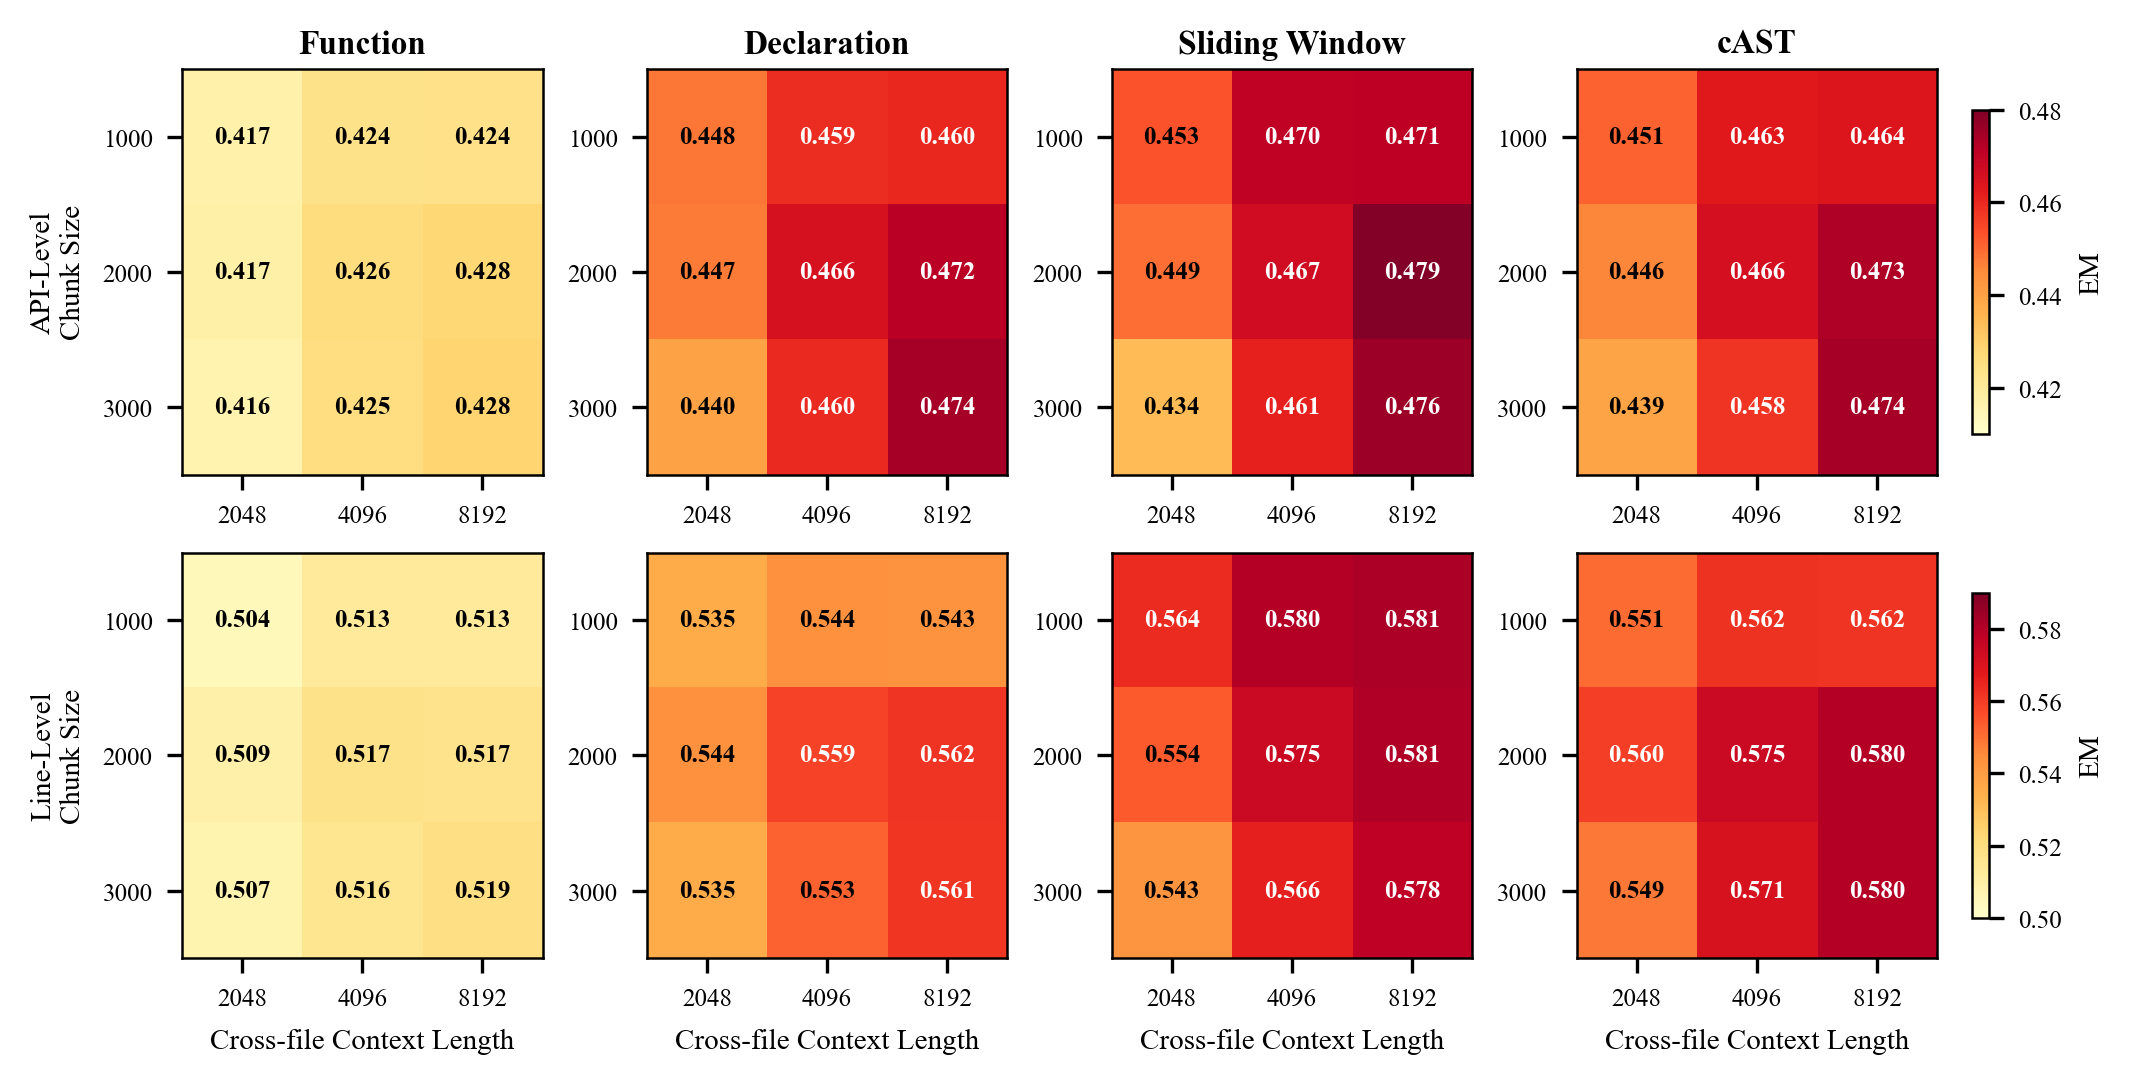

Saved: output/repoeval_rq3_heatmap.pdf


In [40]:
# RQ3 — Heatmap: chunk_size × cross-file context length per strategy (2×4 grid)
# Style adapted from Chunk-legacy/eval/repoeval/visualize_results.ipynb

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
SPLIT_LABELS = {"api": "API-Level", "line": "Line-Level"}
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6,
})

# Pre-compute all grids
grids = {}
all_vals = {s: [] for s in ["api", "line"]}
for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]
    for method in METHOD_ORDER:
        m = sub[sub["method"] == method]
        grid = np.zeros((len(CHUNK_SIZES), len(CONTEXT_LENS)))
        for r, cs in enumerate(CHUNK_SIZES):
            for c, cl in enumerate(CONTEXT_LENS):
                vals = m[(m["max_chunk_size"] == cs) & (m["max_crossfile_context"] == cl)][METRIC].values
                grid[r, c] = np.mean(vals) if len(vals) > 0 else 0
                all_vals[split_name].append(grid[r, c])
        grids[(split_name, method)] = grid

fig, axes = plt.subplots(2, 4, figsize=(7, 3.5), constrained_layout=True)

for row_idx, split_name in enumerate(["api", "line"]):
    vmin = np.floor(min(all_vals[split_name]) * 100) / 100
    vmax = np.ceil(max(all_vals[split_name]) * 100) / 100
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.YlOrRd

    for col_idx, (method, mlabel) in enumerate(zip(METHOD_ORDER, METHOD_LABELS)):
        ax = axes[row_idx, col_idx]
        grid = grids[(split_name, method)]

        im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto")

        for r in range(len(CHUNK_SIZES)):
            for c in range(len(CONTEXT_LENS)):
                val = grid[r, c]
                text_color = "white" if norm(val) > 0.65 else "black"
                ax.text(c, r, f"{val:.3f}", ha="center", va="center",
                        fontsize=6, color=text_color, fontweight="bold")

        ax.set_xticks(range(len(CONTEXT_LENS)))
        ax.set_xticklabels([str(c) for c in CONTEXT_LENS], fontsize=6)
        ax.set_yticks(range(len(CHUNK_SIZES)))
        ax.set_yticklabels([str(c) for c in CHUNK_SIZES], fontsize=6)

        if row_idx == 1:
            ax.set_xlabel("Cross-file Context Length", fontsize=7)
        if col_idx == 0:
            ax.set_ylabel(f"{SPLIT_LABELS[split_name]}\nChunk Size", fontsize=7)

        if row_idx == 0:
            ax.set_title(mlabel, fontweight="bold", fontsize=8, pad=4)

    # Colorbar per row
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[row_idx, :], shrink=0.8, pad=0.02, aspect=20)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label(METRIC, fontsize=7)

fig.savefig(OUTPUT_DIR / "repoeval_rq3_heatmap.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/repoeval_rq3_heatmap.pdf")

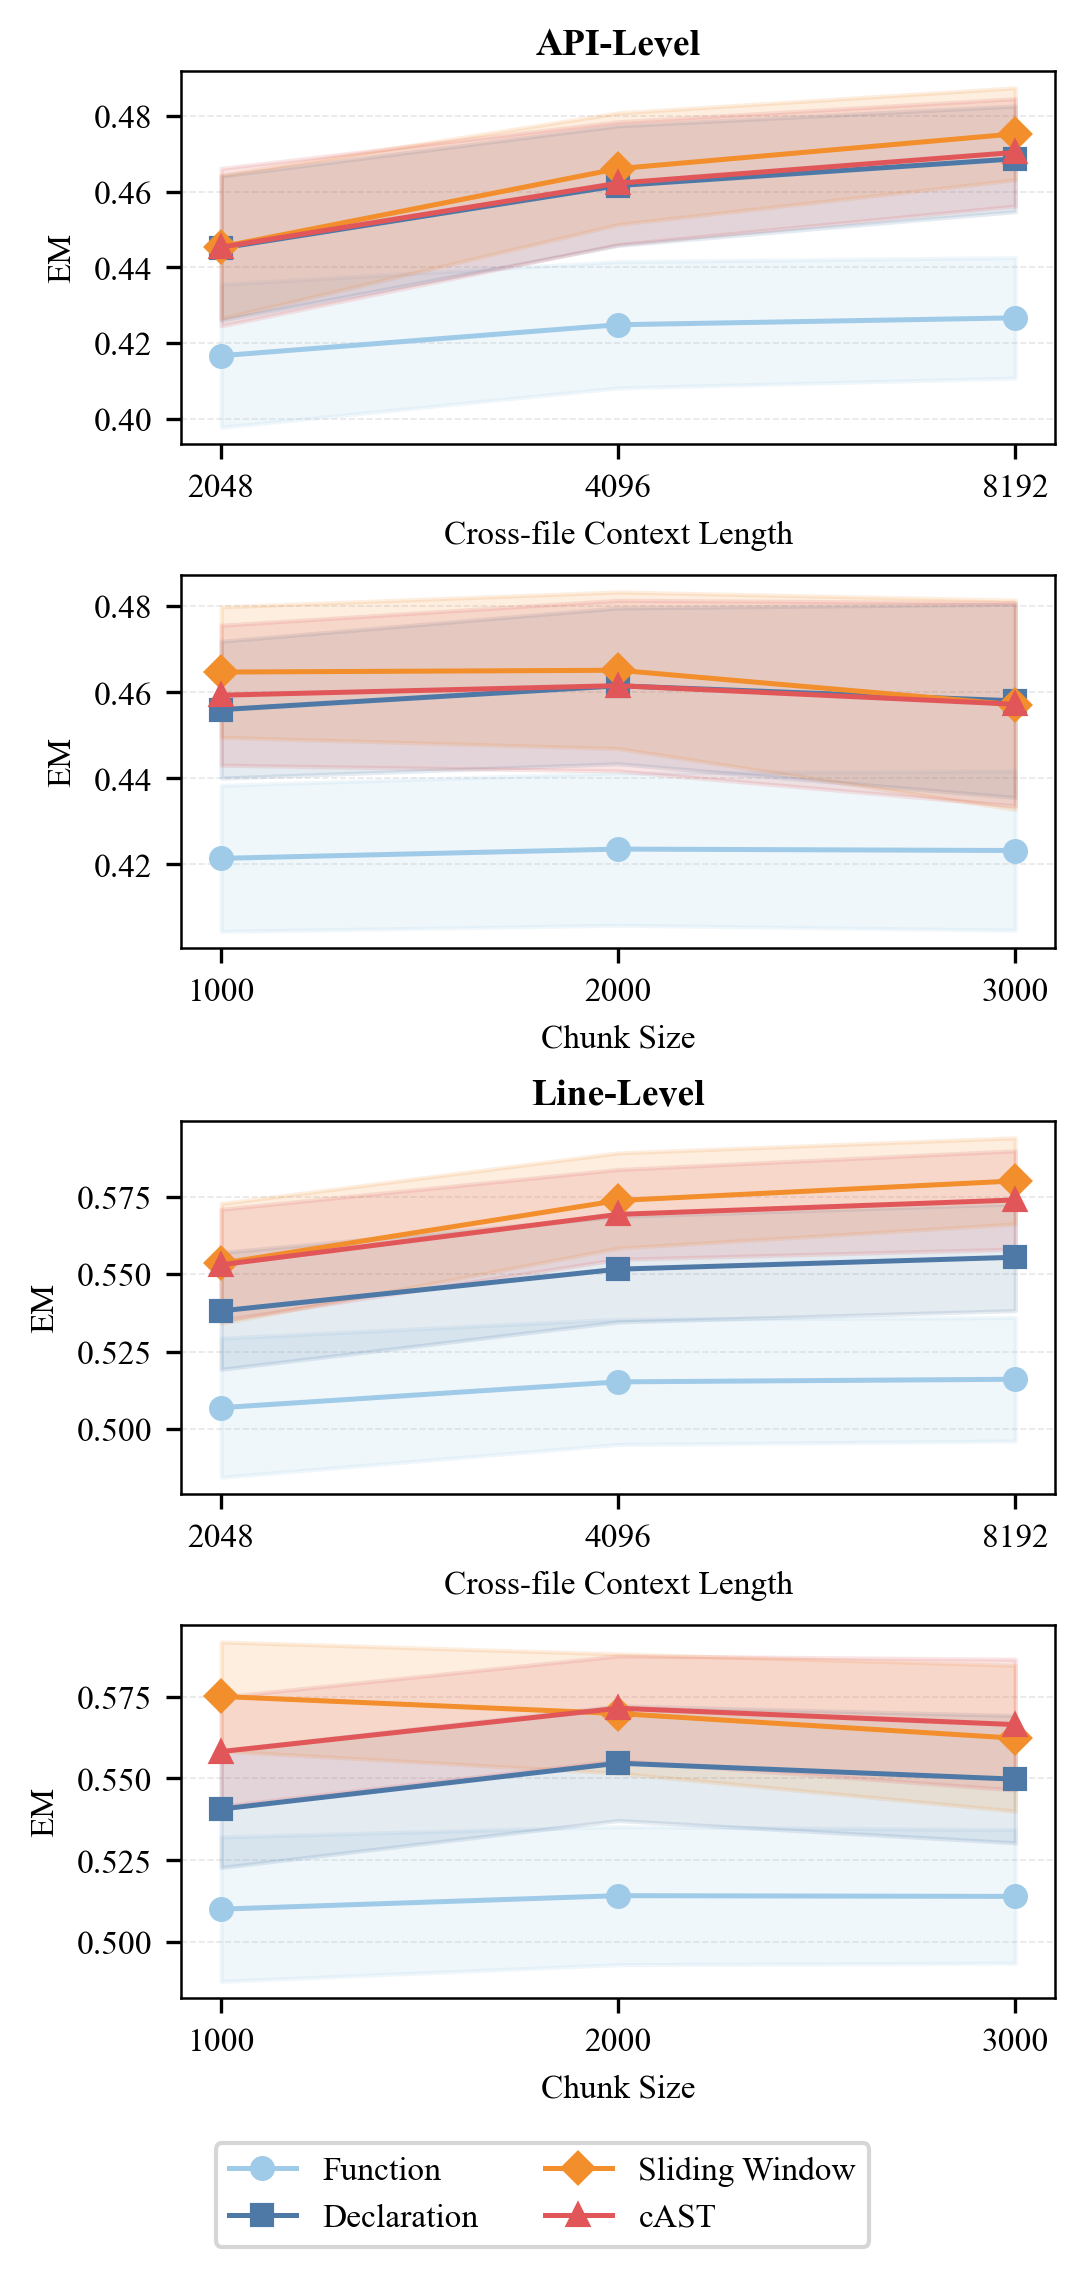

Saved: output/repoeval_rq3_line.pdf


In [41]:
# RQ3 — Line chart: parameter sensitivity (4×1 vertical stack, column-width)
# Layout: 4 rows × 1 col
#   Row 0: API-Level × Cross-file Context Length
#   Row 1: API-Level × Chunk Size
#   Row 2: Line-Level × Cross-file Context Length
#   Row 3: Line-Level × Chunk Size

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

split_configs = [
    (rag[rag["split"] == "api"], "API-Level"),
    (rag[rag["split"] == "line"], "Line-Level"),
]

fig, axes = plt.subplots(4, 1, figsize=(3.5, 7), constrained_layout=True)

row = 0
for sub, task_label in split_configs:
    # Sub-row 0: X = cross-file context length
    ax = axes[row]
    for method, mlabel, color, marker in zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS):
        m = sub[sub["method"] == method]
        means, stds = [], []
        for cl in CONTEXT_LENS:
            vals = m[m["max_crossfile_context"] == cl][METRIC].values
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        means, stds = np.array(means), np.array(stds)
        ax.plot(range(len(CONTEXT_LENS)), means, color=color, marker=marker,
                markersize=5, linewidth=1.2, label=mlabel, zorder=3)
        ax.fill_between(range(len(CONTEXT_LENS)), means - stds, means + stds,
                        color=color, alpha=0.15, zorder=1)
    ax.set_xticks(range(len(CONTEXT_LENS)))
    ax.set_xticklabels([str(c) for c in CONTEXT_LENS])
    ax.set_xlabel("Cross-file Context Length", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(task_label, fontweight="bold", fontsize=9, pad=4)

    # Sub-row 1: X = chunk size
    ax = axes[row + 1]
    for method, mlabel, color, marker in zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS):
        m = sub[sub["method"] == method]
        means, stds = [], []
        for cs in CHUNK_SIZES:
            vals = m[m["max_chunk_size"] == cs][METRIC].values
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        means, stds = np.array(means), np.array(stds)
        ax.plot(range(len(CHUNK_SIZES)), means, color=color, marker=marker,
                markersize=5, linewidth=1.2, label=mlabel, zorder=3)
        ax.fill_between(range(len(CHUNK_SIZES)), means - stds, means + stds,
                        color=color, alpha=0.15, zorder=1)
    ax.set_xticks(range(len(CHUNK_SIZES)))
    ax.set_xticklabels([str(c) for c in CHUNK_SIZES])
    ax.set_xlabel("Chunk Size", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)

    row += 2

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc", fontsize=8)

fig.savefig(OUTPUT_DIR / "repoeval_rq3_line.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/repoeval_rq3_line.pdf")

## RQ3: Parameter Sensitivity — Statistical Tests

Friedman test across 3 levels of each parameter (context length: 2048/4096/8192; chunk size: 1000/2000/3000),
followed by Wilcoxon signed-rank post-hoc with Holm–Bonferroni correction and Cliff's delta effect size.
Each observation = EM of one (method × retriever × LLM × other_param) configuration.

In [42]:
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

def cliffs_delta(x, y):
    n = len(x)
    more = sum(1 for i in range(n) if x[i] > y[i])
    less = sum(1 for i in range(n) if x[i] < y[i])
    return (more - less) / n

def interpret_delta(d):
    d = abs(d)
    if d < 0.147:   return "Negligible"
    elif d < 0.33:  return "Small"
    elif d < 0.474: return "Medium"
    else:           return "Large"

CONTEXT_LENS = [2048, 4096, 8192]
CHUNK_SIZES = [1000, 2000, 3000]
METRIC = "EM"

all_results = []

for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]

    for param_name, param_col, levels in [
        ("Context Length", "max_crossfile_context", CONTEXT_LENS),
        ("Chunk Size", "max_chunk_size", CHUNK_SIZES),
    ]:
        # Build paired observations: each config (method × retriever × LLM × other_param) → one EM per level
        other_param = "max_chunk_size" if param_col == "max_crossfile_context" else "max_crossfile_context"
        pivot = sub.pivot_table(
            index=["method", "retriever", "llm", other_param],
            columns=param_col, values=METRIC
        )
        pivot = pivot.dropna()

        # Friedman test across 3 levels
        groups = [pivot[lv].values for lv in levels]
        fri_stat, fri_p = friedmanchisquare(*groups)

        # Post-hoc: pairwise Wilcoxon + Cliff's delta
        pairs = list(combinations(levels, 2))
        p_values = []
        posthoc = []
        for a, b in pairs:
            x, y = pivot[a].values, pivot[b].values
            stat, p = wilcoxon(x, y)
            delta = cliffs_delta(y, x)  # positive delta means b > a
            p_values.append(p)
            posthoc.append({
                "split": split_name,
                "parameter": param_name,
                "level_A": a,
                "level_B": b,
                "wilcoxon_stat": stat,
                "p_raw": p,
                "cliffs_delta": round(delta, 4),
                "effect_size": interpret_delta(delta),
            })

        rejected, corrected_p, _, _ = multipletests(p_values, method="holm")
        for i, r in enumerate(posthoc):
            r["p_corrected"] = corrected_p[i]
            r["significant"] = "Yes" if rejected[i] else "No"

        print(f"=== {split_name.upper()} — {param_name} ===")
        print(f"Friedman χ² = {fri_stat:.2f}, p = {fri_p:.2e}")
        print()

        all_results.extend(posthoc)

rq3_stat_df = pd.DataFrame(all_results)
rq3_stat_df = rq3_stat_df[["split", "parameter", "level_A", "level_B",
                            "wilcoxon_stat", "p_raw", "p_corrected",
                            "significant", "cliffs_delta", "effect_size"]]

rq3_stat_df.to_csv(OUTPUT_DIR / "repoeval_rq3_statistical_tests.csv", index=False)
print("Exported to output/repoeval_rq3_statistical_tests.csv\n")
print(rq3_stat_df.to_string(index=False))

=== API — Context Length ===
Friedman χ² = 326.47, p = 1.28e-71

=== API — Chunk Size ===
Friedman χ² = 32.70, p = 7.91e-08

=== LINE — Context Length ===
Friedman χ² = 305.28, p = 5.11e-67

=== LINE — Chunk Size ===
Friedman χ² = 70.15, p = 5.85e-16

Exported to output/repoeval_rq3_statistical_tests.csv

split      parameter  level_A  level_B  wilcoxon_stat        p_raw  p_corrected significant  cliffs_delta effect_size
  api Context Length     2048     4096           13.5 3.624018e-33 1.087205e-32         Yes        0.9792       Large
  api Context Length     2048     8192            0.0 4.278695e-33 1.087205e-32         Yes        0.9948       Large
  api Context Length     4096     8192          833.0 8.414237e-24 8.414237e-24         Yes        0.6094       Large
  api     Chunk Size     1000     2000         5557.5 8.506144e-06 1.701229e-05         Yes        0.2917       Small
  api     Chunk Size     1000     3000         8371.5 5.731981e-01 5.731981e-01          No        0.01

## RQ4: Cost Trade-off — Scatter Plot

X = avg_token_cost, Y = EM.
Each point = one configuration.
Marker shape = chunking method.
Draw Pareto front connecting non-dominated points.

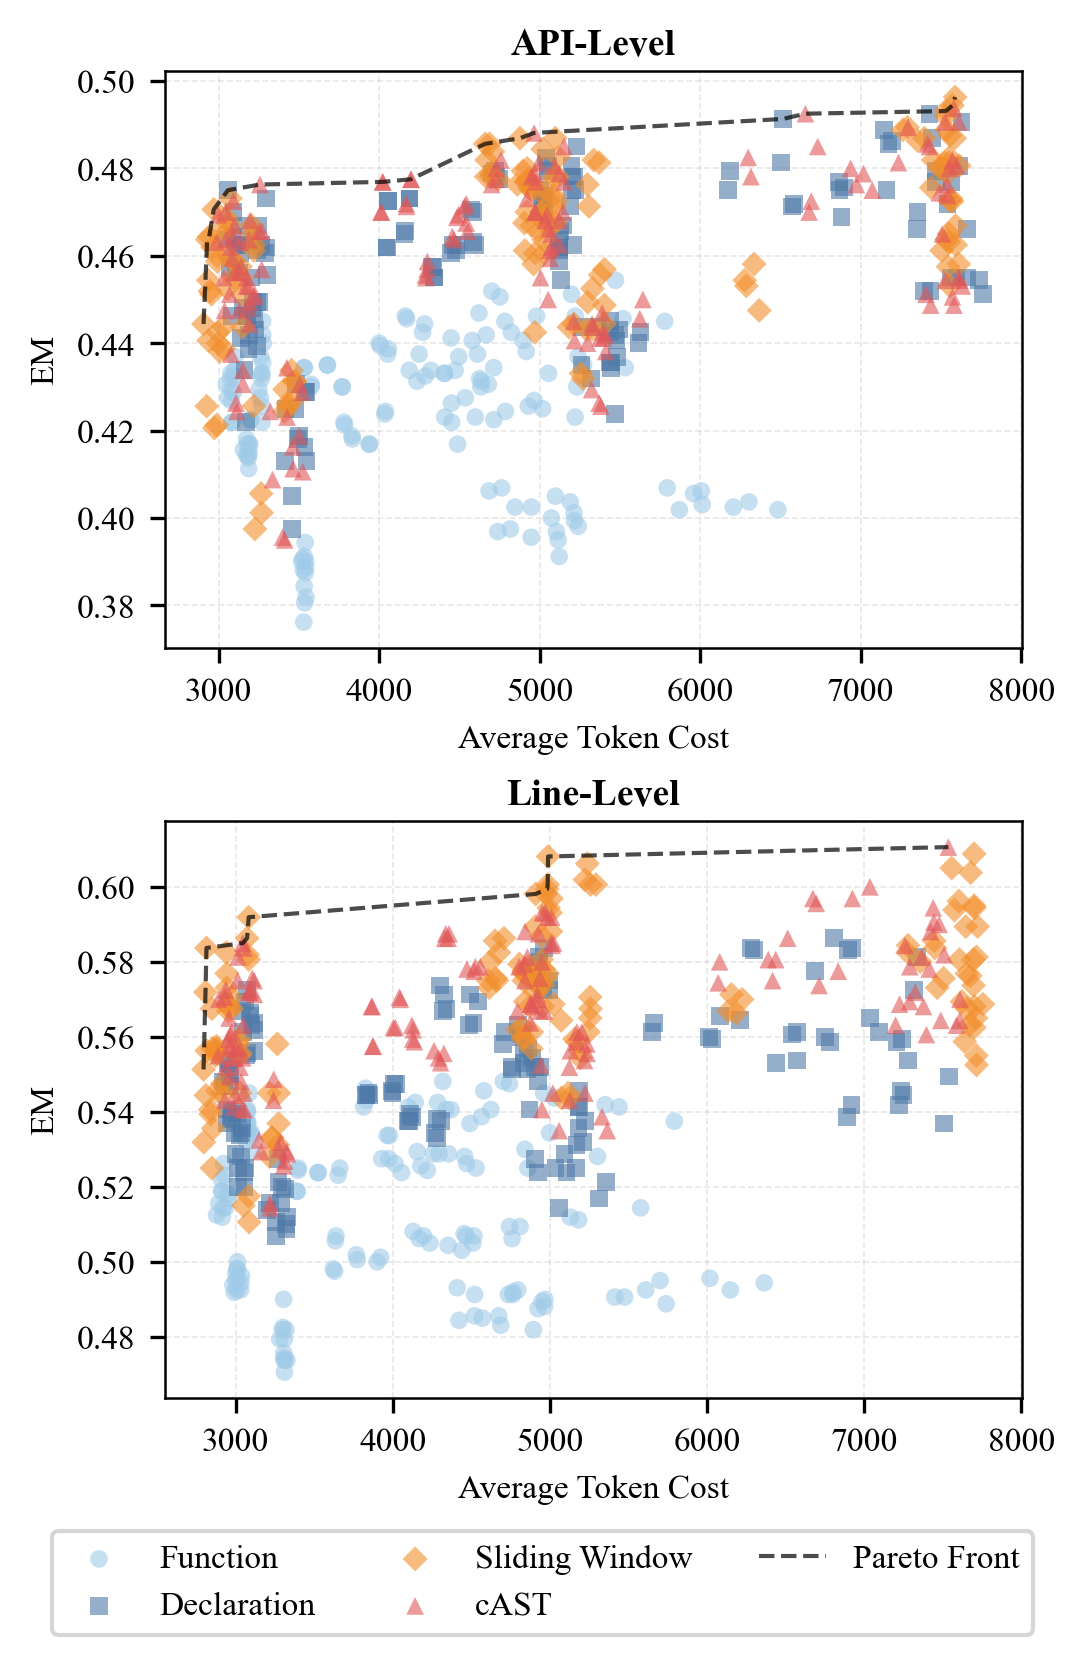

Saved: output/repoeval_rq4_pareto.pdf


In [43]:
# RQ4 — Cost-performance scatter plot with Pareto front (2×1 vertical, column-width)
# Layout: 2 rows × 1 col (top: API-Level, bottom: Line-Level)

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
METRIC = "EM"
COST_COL = "avg_token_cost"

def pareto_front(costs, scores):
    """Return indices of Pareto-optimal points (lower cost, higher score)."""
    points = list(zip(costs, scores, range(len(costs))))
    points.sort(key=lambda x: x[0])  # sort by cost ascending
    front = []
    best_score = -np.inf
    for cost, score, idx in points:
        if score > best_score:
            front.append(idx)
            best_score = score
    return front

fig, axes = plt.subplots(2, 1, figsize=(3.5, 5), constrained_layout=True)

for row_idx, split_name in enumerate(["api", "line"]):
    ax = axes[row_idx]
    sub = rag[rag["split"] == split_name]

    agg = sub.groupby(["method", "retriever", "llm", "max_chunk_size", "max_crossfile_context"]).agg(
        em=(METRIC, "mean"),
        cost=(COST_COL, "mean"),
    ).reset_index()

    for method, mlabel, color, marker in zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS):
        m = agg[agg["method"] == method]
        ax.scatter(m["cost"], m["em"], c=color, marker=marker,
                   s=18, alpha=0.6, label=mlabel, edgecolors="none", zorder=2)

    all_costs = agg["cost"].values
    all_ems = agg["em"].values
    front_idx = pareto_front(all_costs, all_ems)
    front_costs = all_costs[front_idx]
    front_ems = all_ems[front_idx]
    sort_order = np.argsort(front_costs)
    ax.plot(front_costs[sort_order], front_ems[sort_order],
            color="black", linewidth=1.0, linestyle="--", alpha=0.7, zorder=3, label="Pareto Front")

    ax.set_xlabel("Average Token Cost", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.set_title({"api": "API-Level", "line": "Line-Level"}[split_name],
                 fontweight="bold", fontsize=9, pad=4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.xaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.09), frameon=True, edgecolor="#cccccc", fontsize=8)

fig.savefig(OUTPUT_DIR / "repoeval_rq4_pareto.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/repoeval_rq4_pareto.pdf")

## Ablation: Sliding Window Overlap

Mean EM across overlap_lines values (0, 5, 10, 15, 20, 25), averaged over retriever × LLM × chunk_size.

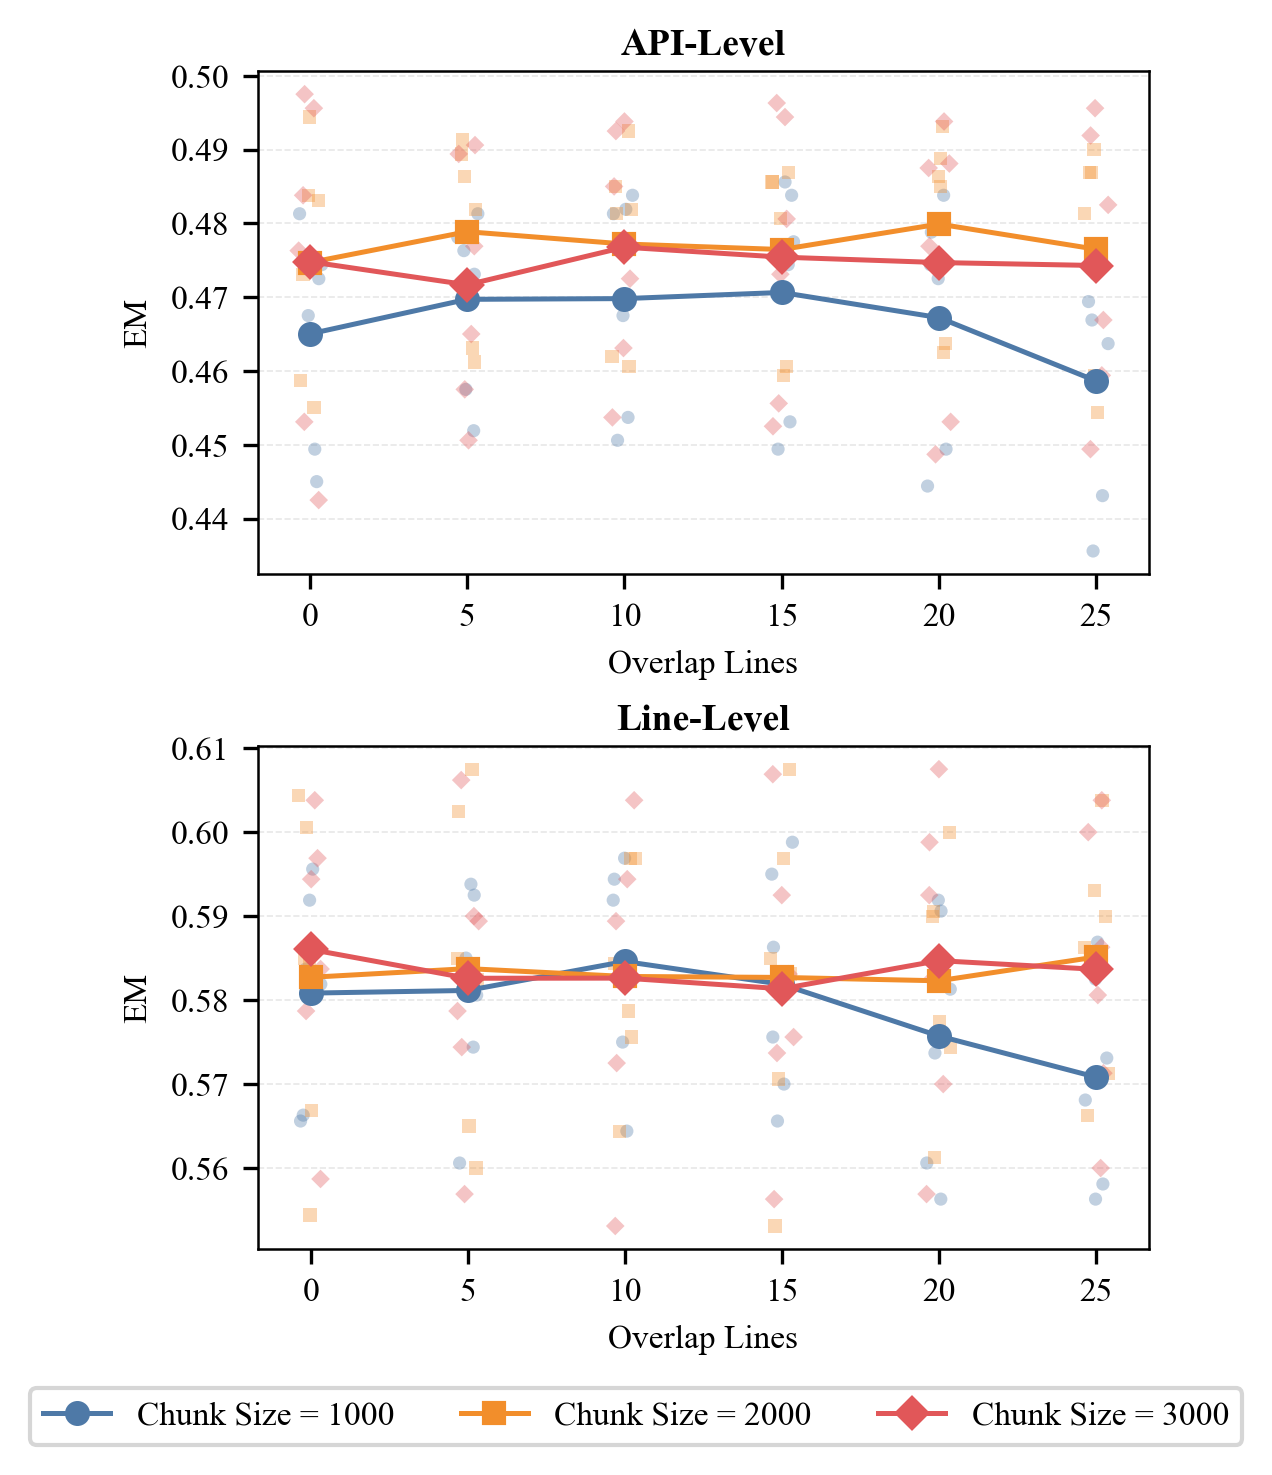

Saved: output/repoeval_ablation_overlap.pdf


In [44]:
# Ablation: Sliding Window Overlap — Scatter + Line chart (2×1 vertical, column-width)
# Layout: 2 rows × 1 col (top: API-Level, bottom: Line-Level)
# Individual config points (scatter) + mean trend line per chunk_size

ablation_df = pd.read_csv(RESULT_DIR / "ablation_overlap.csv")

OVERLAP_VALUES = [0, 5, 10, 15, 20, 25]
CHUNK_SIZES = [1000, 2000, 3000]
CHUNK_COLORS = ['#4E79A7', '#F28E2B', '#E15759']
CHUNK_MARKERS = ['o', 's', 'D']
METRIC = "EM"

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 1, figsize=(3.5, 4.5), constrained_layout=True)

for row_idx, split_name in enumerate(["api", "line"]):
    ax = axes[row_idx]
    sub = ablation_df[ablation_df["split"] == split_name]

    for cs, color, marker in zip(CHUNK_SIZES, CHUNK_COLORS, CHUNK_MARKERS):
        means = []
        for i, ov in enumerate(OVERLAP_VALUES):
            vals = sub[(sub["max_chunk_size"] == cs) & (sub["overlap_lines"] == ov)][METRIC].values
            means.append(np.mean(vals))
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, c=color, marker=marker,
                       s=10, alpha=0.35, edgecolors="none", zorder=2)
        means = np.array(means)
        ax.plot(range(len(OVERLAP_VALUES)), means, color=color, marker=marker,
                markersize=5, linewidth=1.2, label=f"Chunk Size = {cs}", zorder=3)

    ax.set_xticks(range(len(OVERLAP_VALUES)))
    ax.set_xticklabels([str(v) for v in OVERLAP_VALUES])
    ax.set_xlabel("Overlap Lines", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.set_title({"api": "API-Level", "line": "Line-Level"}[split_name],
                 fontweight="bold", fontsize=9, pad=4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc", fontsize=8)

fig.savefig(OUTPUT_DIR / "repoeval_ablation_overlap.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/repoeval_ablation_overlap.pdf")

In [45]:
# Ablation: Sliding Window Overlap — Export mean EM per (split × chunk_size × overlap_lines)

ablation_df = pd.read_csv(RESULT_DIR / "ablation_overlap.csv")

abl_summary = ablation_df.groupby(["split", "max_chunk_size", "overlap_lines"])["EM"].agg(["mean", "std", "count"]).reset_index()
abl_summary.columns = ["split", "chunk_size", "overlap_lines", "EM_mean", "EM_std", "n"]
abl_summary = abl_summary.sort_values(["split", "chunk_size", "overlap_lines"])
abl_summary["EM_mean"] = abl_summary["EM_mean"].round(4)
abl_summary["EM_std"] = abl_summary["EM_std"].round(4)

abl_summary.to_csv(OUTPUT_DIR / "repoeval_ablation_overlap_summary.csv", index=False)
print("Exported to output/repoeval_ablation_overlap_summary.csv\n")
print(abl_summary.to_string(index=False))

Exported to output/repoeval_ablation_overlap_summary.csv

split  chunk_size  overlap_lines  EM_mean  EM_std  n
  api        1000              0   0.4650  0.0146  6
  api        1000              5   0.4697  0.0120  6
  api        1000             10   0.4698  0.0149  6
  api        1000             15   0.4706  0.0156  6
  api        1000             20   0.4672  0.0163  6
  api        1000             25   0.4586  0.0154  6
  api        2000              0   0.4747  0.0154  6
  api        2000              5   0.4789  0.0133  6
  api        2000             10   0.4772  0.0130  6
  api        2000             15   0.4764  0.0129  6
  api        2000             20   0.4799  0.0133  6
  api        2000             25   0.4765  0.0155  6
  api        3000              0   0.4748  0.0226  6
  api        3000              5   0.4717  0.0167  6
  api        3000             10   0.4768  0.0164  6
  api        3000             15   0.4754  0.0187  6
  api        3000             20   0.4747

## Partial-Correct Positional Analysis

For instances where EM ≠ 1 (across all four methods), examine the **positional distribution** of character-level matches between `completion` and `ground_truth`:

1. **Prefix match ratio** — how far from the start does the completion stay correct?
2. **Positional match rate** — at each normalized position (0%–100%) in the ground truth, what fraction of characters are correctly predicted?
3. **Disagree-only subset** — restricted to instances where chunk methods disagree on EM.

In [46]:
import json, os
from collections import defaultdict

COMPLETION_DIR = Path("../repoeval/completion")
PC_METHODS = ['cast', 'declaration', 'function', 'sliding']
PC_LABELS = {'cast': 'cAST', 'declaration': 'Declaration',
             'function': 'Function', 'sliding': 'Sliding Window'}
PC_COLORS = {'function': '#A0CBE8', 'declaration': '#4E79A7',
             'sliding': '#F28E2B', 'cast': '#E15759'}

def _compute_EM(target, prediction):
    tl = [l.strip() for l in target.splitlines() if l.strip()]
    pl = [l.strip() for l in prediction.splitlines() if l.strip()][:len(tl)]
    return len(tl) == len(pl) and tl == pl

def _truncate(gt, pred):
    gl = gt.splitlines(); pl = pred.splitlines()[:len(gl)]
    while len(pl) < len(gl): pl.append("")
    return "\n".join(pl)

def _prefix_len(gt, pred):
    n = min(len(gt), len(pred))
    for i in range(n):
        if gt[i] != pred[i]: return i
    return n

def _load_jsonl(fp):
    with open(fp) as f:
        lines = [json.loads(l) for l in f]
    if lines and "total_inference_time" in lines[-1]:
        lines = lines[:-1]
    return lines

# Load completion results
pc_data = {}
for ret in os.listdir(COMPLETION_DIR):
    rp = COMPLETION_DIR / ret
    if not rp.is_dir() or ret == "ablation_overlap": continue
    for llm in os.listdir(rp):
        lp = rp / llm
        if not lp.is_dir(): continue
        for fn in os.listdir(lp):
            if not fn.endswith(".jsonl"): continue
            parts = fn.replace(".jsonl", "").split("_")
            sp, mt, cs = parts[0], parts[1], parts[2]
            if mt == "baseline": continue
            try:
                pc_data[(ret, llm, sp, mt, cs)] = _load_jsonl(str(lp / fn))
            except: pass

pc_groups = defaultdict(dict)
for (ret, llm, sp, mt, cs), lines in pc_data.items():
    pc_groups[(ret, llm, sp, cs)][mt] = lines

print(f"Loaded {len(pc_data)} configs, {len(pc_groups)} groups")

Loaded 192 configs, 48 groups


In [47]:
N_BINS = 20

prefix_ratios = {m: [] for m in PC_METHODS}
pos_match  = {m: np.zeros(N_BINS) for m in PC_METHODS}
pos_total  = {m: np.zeros(N_BINS) for m in PC_METHODS}
dis_match  = {m: np.zeros(N_BINS) for m in PC_METHODS}
dis_total  = {m: np.zeros(N_BINS) for m in PC_METHODS}

for gk, md in pc_groups.items():
    if not all(m in md for m in PC_METHODS):
        continue
    n = min(len(md[m]) for m in PC_METHODS)
    for idx in range(n):
        gt = md[PC_METHODS[0]][idx]["ground_truth"]
        gt_len = len(gt)
        if gt_len == 0:
            continue

        ems, preds = {}, {}
        for m in PC_METHODS:
            pred = md[m][idx]["completion"]
            preds[m] = _truncate(gt, pred)
            ems[m] = _compute_EM(gt, pred)

        if all(ems[m] for m in PC_METHODS):
            continue  # skip all-correct

        is_dis = len(set(ems[m] for m in PC_METHODS)) > 1

        for m in PC_METHODS:
            if ems[m]:
                prefix_ratios[m].append(1.0)
                for b in range(N_BINS):
                    pos_match[m][b] += 1; pos_total[m][b] += 1
                if is_dis:
                    for b in range(N_BINS):
                        dis_match[m][b] += 1; dis_total[m][b] += 1
                continue

            pt = preds[m]
            prefix_ratios[m].append(_prefix_len(gt, pt) / gt_len)
            pl = len(pt)
            for ci in range(gt_len):
                b = min(int(ci / gt_len * N_BINS), N_BINS - 1)
                pos_total[m][b] += 1
                if ci < pl and gt[ci] == pt[ci]:
                    pos_match[m][b] += 1
                if is_dis:
                    dis_total[m][b] += 1
                    if ci < pl and gt[ci] == pt[ci]:
                        dis_match[m][b] += 1

pos_rate = {m: pos_match[m] / np.where(pos_total[m] > 0, pos_total[m], 1) for m in PC_METHODS}
dis_rate = {m: dis_match[m] / np.where(dis_total[m] > 0, dis_total[m], 1) for m in PC_METHODS}

print(f"Instances per method: {len(prefix_ratios[PC_METHODS[0]])}")

Instances per method: 43850


/var/folders/md/50vf4y090yscs2yh0x03c0hm0000gp/T/ipykernel_60210/1817193949.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5,


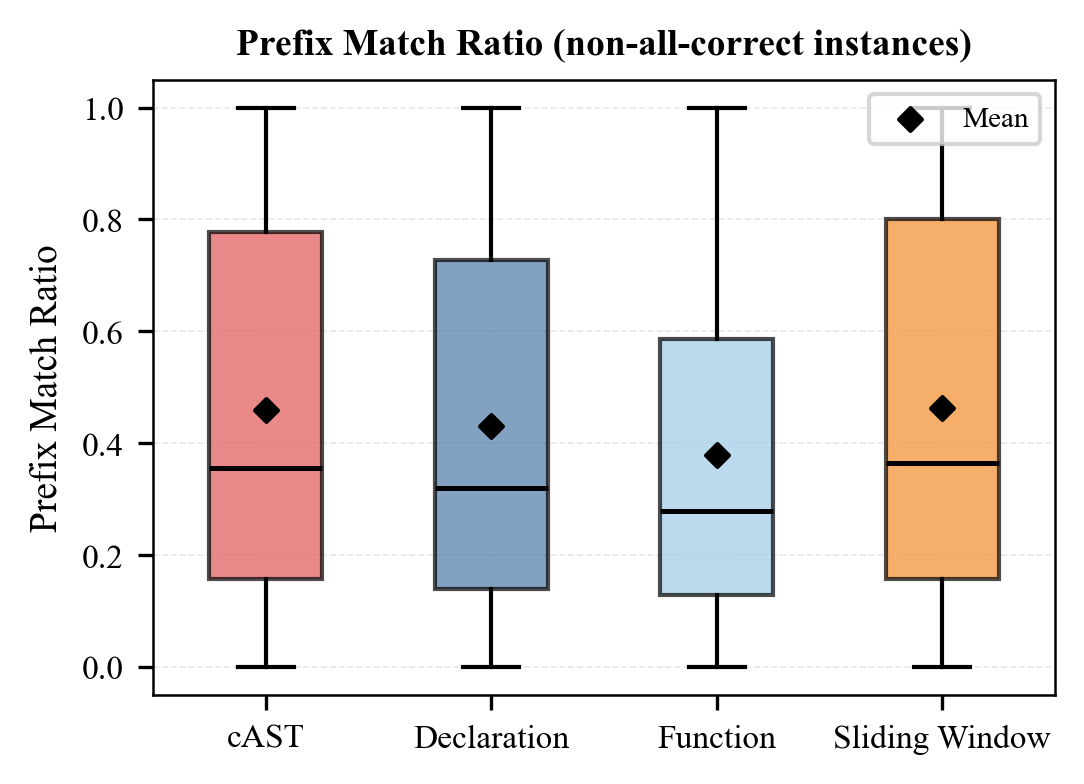

Method                 Mean   Median      P25      P75
--------------------------------------------------
cAST                  0.459    0.356    0.157    0.778
Declaration           0.431    0.320    0.139    0.728
Function              0.379    0.279    0.129    0.587
Sliding Window        0.464    0.364    0.157    0.800


In [48]:
# Figure: Prefix Match Ratio — Box Plot
fig, ax = plt.subplots(figsize=(3.5, 2.5), constrained_layout=True)

box_data = [prefix_ratios[m] for m in PC_METHODS]
labels = [PC_LABELS[m] for m in PC_METHODS]
colors = [PC_COLORS[m] for m in PC_METHODS]

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5,
                showfliers=False, medianprops=dict(color='black', linewidth=1.2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)

means = [np.mean(v) for v in box_data]
ax.scatter(range(1, len(PC_METHODS)+1), means, marker='D', color='black', s=15, zorder=5, label='Mean')

ax.set_ylabel("Prefix Match Ratio")
ax.set_title("Prefix Match Ratio (non-all-correct instances)", fontweight="bold", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=7, loc="upper right")

fig.savefig(OUTPUT_DIR / "repoeval_prefix_match_boxplot.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"{'Method':<18} {'Mean':>8} {'Median':>8} {'P25':>8} {'P75':>8}")
print("-"*50)
for m in PC_METHODS:
    v = prefix_ratios[m]
    qs = np.quantile(v, [0.25, 0.5, 0.75])
    print(f"{PC_LABELS[m]:<18} {np.mean(v):>8.3f} {qs[1]:>8.3f} {qs[0]:>8.3f} {qs[2]:>8.3f}")

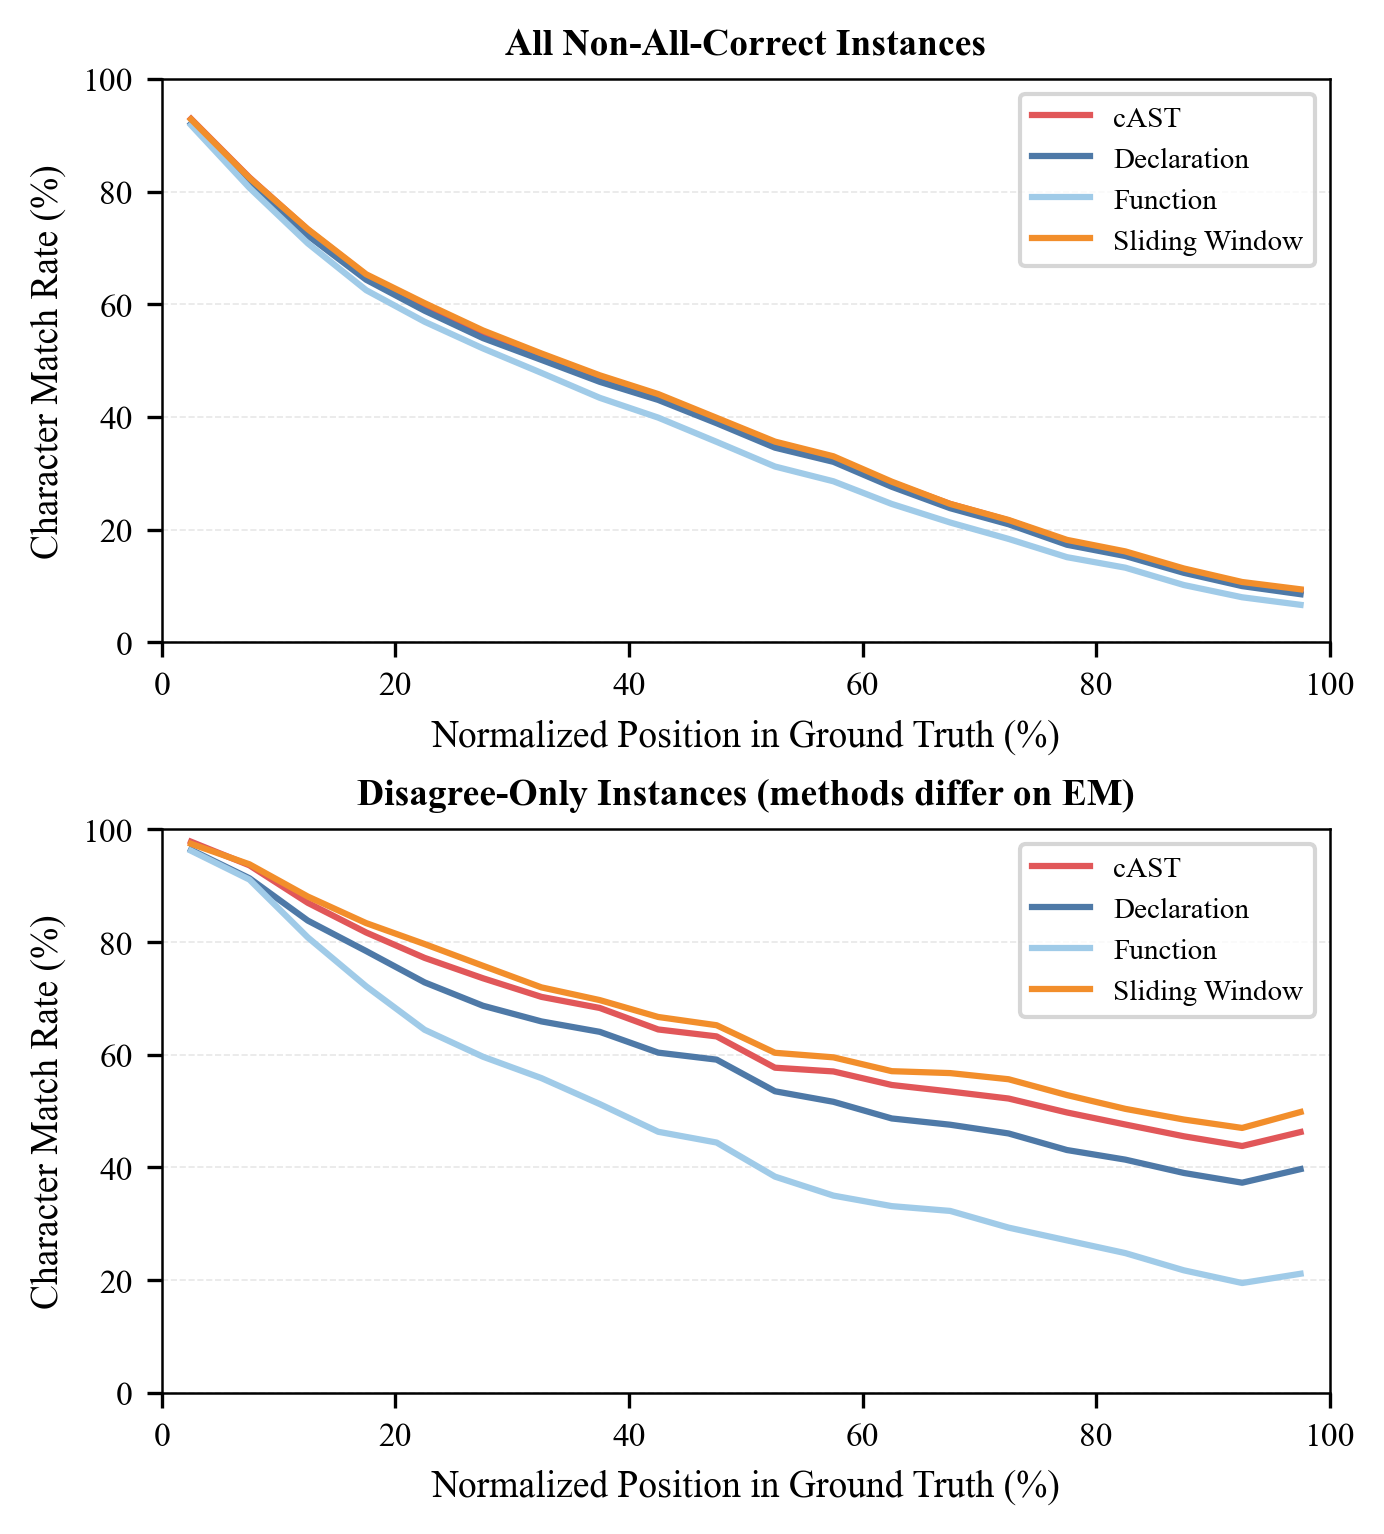


=== Positional Match Rate (%) — All Non-All-Correct ===
Position              cAST     Declaration        Function  Sliding Window
---------------------------------------------------------------------------
 0-5    %           92.9%           92.0%           91.8%           92.8%
 5-10   %           82.5%           81.5%           80.7%           82.4%
10-15   %           73.2%           72.2%           70.8%           73.3%
15-20   %           65.2%           64.4%           62.5%           65.3%
20-25   %           59.9%           58.9%           56.9%           60.2%
25-30   %           54.9%           54.0%           52.2%           55.4%
30-35   %           51.0%           50.1%           47.8%           51.3%
35-40   %           47.0%           46.2%           43.4%           47.4%
40-45   %           43.7%           43.0%           39.9%           44.1%
45-50   %           39.5%           38.9%           35.6%           39.8%
50-55   %           35.2%           34.5%           

In [49]:
# Figure: Positional Match Rate (2 rows: all non-all-correct, disagree-only)
bin_centers = np.arange(N_BINS) / N_BINS * 100 + 100 / N_BINS / 2

fig, axes = plt.subplots(2, 1, figsize=(4.5, 5), constrained_layout=True)

for ax, rd, title in [
    (axes[0], pos_rate, "All Non-All-Correct Instances"),
    (axes[1], dis_rate, "Disagree-Only Instances (methods differ on EM)"),
]:
    for m in PC_METHODS:
        ax.plot(bin_centers, rd[m] * 100, color=PC_COLORS[m],
                linewidth=1.5, label=PC_LABELS[m])
    ax.set_xlabel("Normalized Position in Ground Truth (%)")
    ax.set_ylabel("Character Match Rate (%)")
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7, loc="upper right")

fig.savefig(OUTPUT_DIR / "repoeval_positional_match_rate.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

# Print tables
for label, rd in [("All Non-All-Correct", pos_rate), ("Disagree-Only", dis_rate)]:
    print(f"\n=== Positional Match Rate (%) — {label} ===")
    header = f"{'Position':<10}"
    for m in PC_METHODS: header += f"{PC_LABELS[m]:>16}"
    print(header); print("-"*75)
    for b in range(N_BINS):
        lo, hi = b*100//N_BINS, (b+1)*100//N_BINS
        row = f"{lo:>2}-{hi:<5}%"
        for m in PC_METHODS: row += f"{rd[m][b]*100:>15.1f}%"
        print(row)

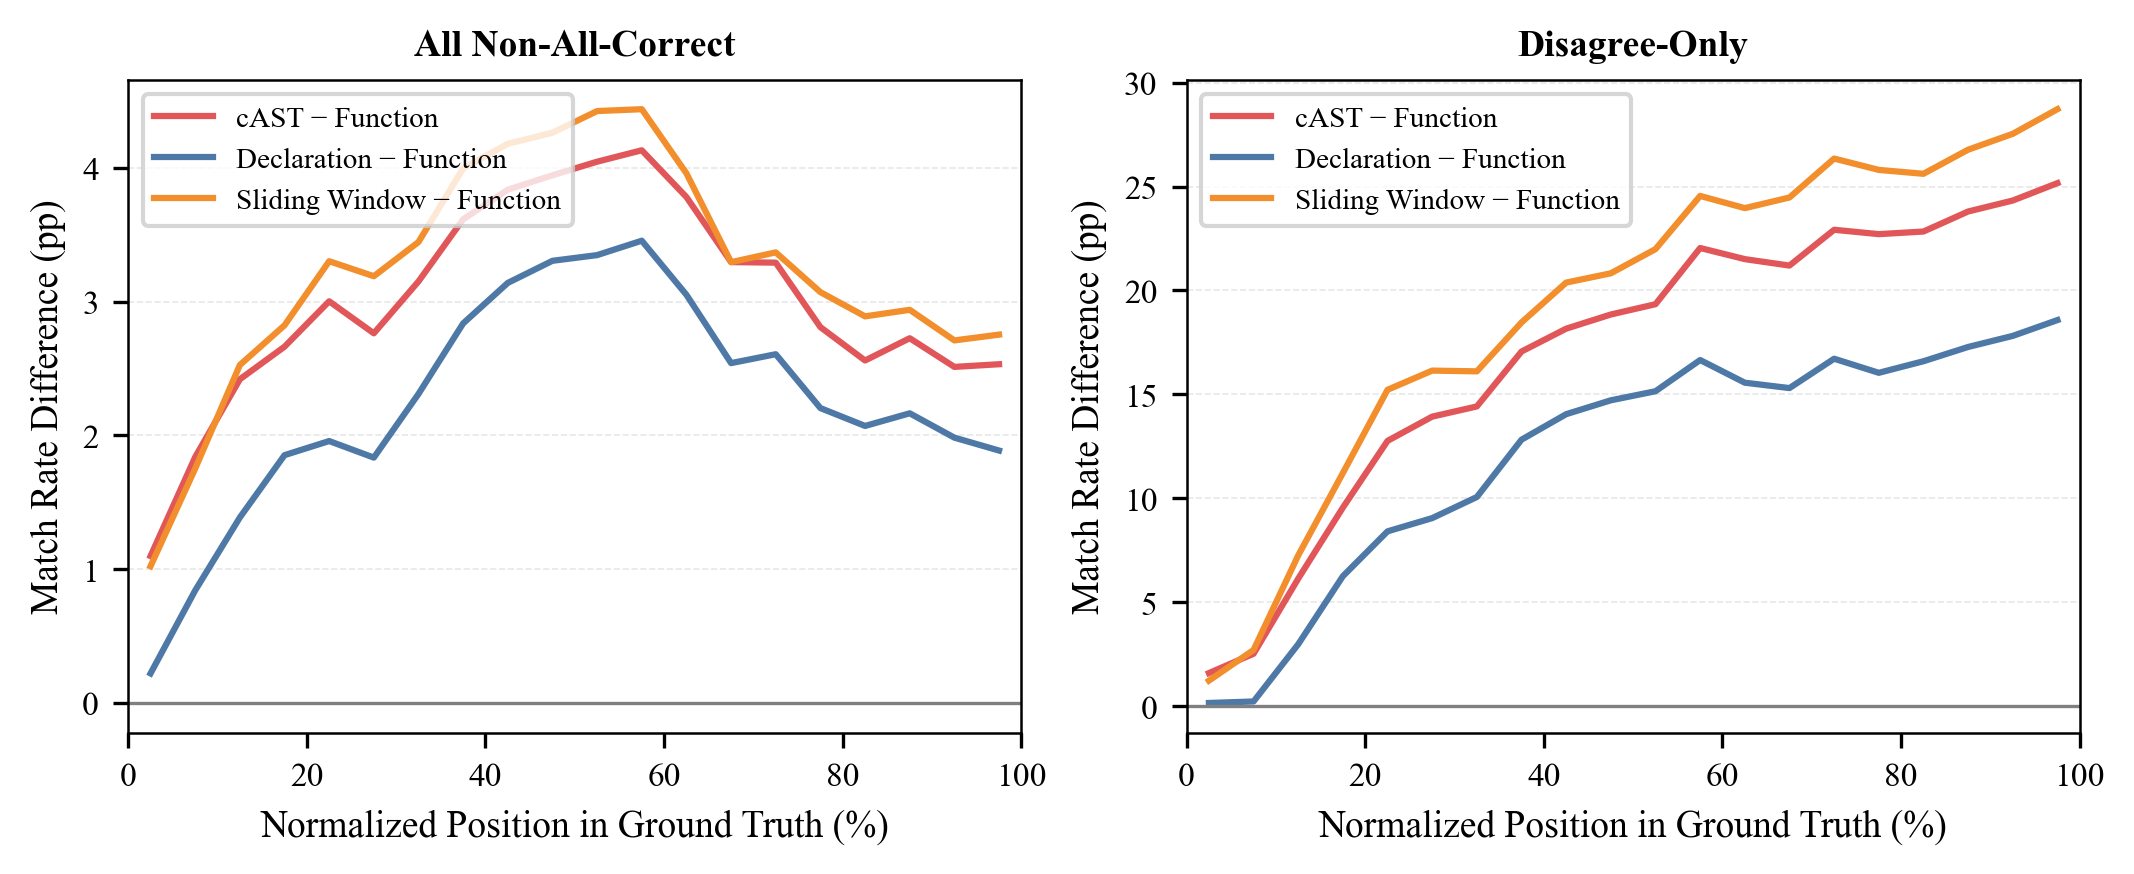

In [50]:
# Figure: Positional match rate difference vs Function (baseline)
fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), constrained_layout=True)

for ax, rd, title in [
    (axes[0], pos_rate, "All Non-All-Correct"),
    (axes[1], dis_rate, "Disagree-Only"),
]:
    func_r = rd['function']
    for m in PC_METHODS:
        if m == 'function': continue
        diff = (rd[m] - func_r) * 100
        ax.plot(bin_centers, diff, color=PC_COLORS[m],
                linewidth=1.5, label=f"{PC_LABELS[m]} − Function")
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
    ax.set_xlabel("Normalized Position in Ground Truth (%)")
    ax.set_ylabel("Match Rate Difference (pp)")
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_xlim(0, 100)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7, loc="upper left")

fig.savefig(OUTPUT_DIR / "repoeval_positional_diff_vs_function.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [51]:
# Export CSV summaries
rows = []
for b in range(N_BINS):
    lo, hi = b*100//N_BINS, (b+1)*100//N_BINS
    row = {"position": f"{lo}-{hi}%"}
    for m in PC_METHODS:
        row[f"{m}_all"] = round(pos_rate[m][b] * 100, 2)
        row[f"{m}_disagree"] = round(dis_rate[m][b] * 100, 2)
    rows.append(row)

csv_df = pd.DataFrame(rows)
csv_df.to_csv(OUTPUT_DIR / "repoeval_positional_match_rate.csv", index=False)

prefix_rows = []
for m in PC_METHODS:
    v = prefix_ratios[m]
    qs = np.quantile(v, [0.25, 0.5, 0.75])
    prefix_rows.append({
        "method": PC_LABELS[m], "count": len(v),
        "mean": round(np.mean(v), 4), "median": round(qs[1], 4),
        "p25": round(qs[0], 4), "p75": round(qs[2], 4),
        "ratio_eq0%": round(sum(1 for x in v if x == 0)/len(v)*100, 2),
        "ratio_lt50%": round(sum(1 for x in v if x < 0.5)/len(v)*100, 2),
        "ratio_ge80%": round(sum(1 for x in v if x >= 0.8)/len(v)*100, 2),
        "ratio_eq100%": round(sum(1 for x in v if x >= 0.999)/len(v)*100, 2),
    })

prefix_df = pd.DataFrame(prefix_rows)
prefix_df.to_csv(OUTPUT_DIR / "repoeval_prefix_match_summary.csv", index=False)

print("Exported: repoeval_positional_match_rate.csv, repoeval_prefix_match_summary.csv")
print(prefix_df.to_string(index=False))

Exported: repoeval_positional_match_rate.csv, repoeval_prefix_match_summary.csv
        method  count   mean  median    p25    p75  ratio_eq0%  ratio_lt50%  ratio_ge80%  ratio_eq100%
          cAST  43850 0.4589  0.3562 0.1567 0.7778        3.97        59.77        24.38         17.27
   Declaration  43850 0.4309  0.3200 0.1393 0.7280        5.58        63.01        21.99         15.26
      Function  43850 0.3795  0.2787 0.1290 0.5870        6.06        69.30        15.11          8.21
Sliding Window  43850 0.4636  0.3636 0.1569 0.8000        3.95        59.21        25.02         17.99
